In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [ ]:
class PolynomialRegression:
    def __init__(self, degree=2):
        self.degree = degree
        self.coefficients_ = None
        self.intercept_ = None
        self.r2score_ = None
        self.poly_features = None
        
    def fit(self, X, y):
        self.poly_features = PolynomialFeatures(degree=self.degree, include_bias=True)
        X_poly = self.poly_features.fit_transform(X)
        # Normal equation
        self.coefficients_ = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        # Predictions and R2
        y_pred = X_poly.dot(self.coefficients_)
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred
        
    def predict(self, X):
        X_poly = self.poly_features.transform(X)
        return X_poly.dot(self.coefficients_)
    
    

In [3]:
dfMonth=pd.read_csv("../DataFrames/tempByMonth.csv", index_col='Unnamed: 0')
print(dfMonth.head())

     Month  Year    TempAvg
0  January  1869  34.596774
1  January  1870  37.693548
2  January  1871  27.838710
3  January  1872  29.129032
4  January  1873  27.354839


Simple LR Coefficients:  [2.03598257 0.99829631 0.50001921]
R2 Score:  0.9999996807319416


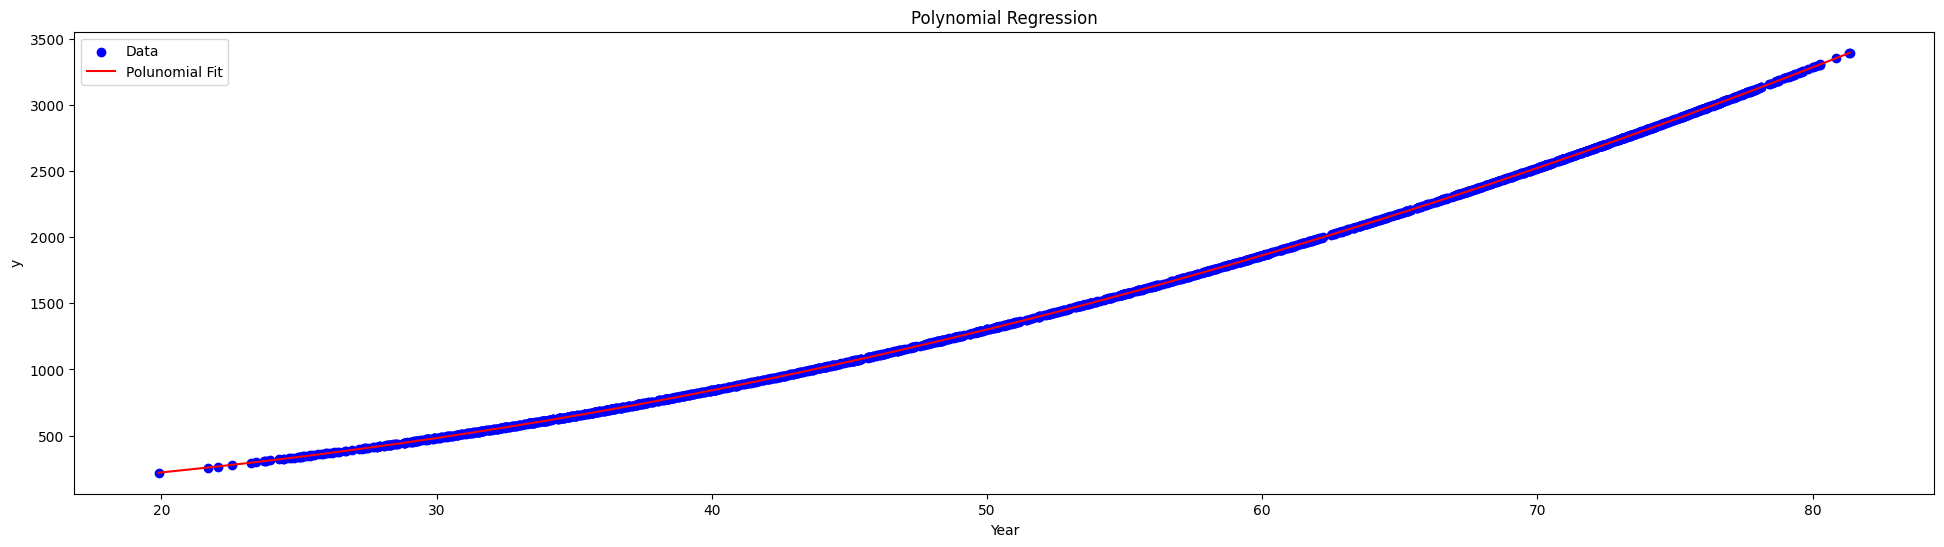

In [4]:
#For Month
Xmonth=np.array(dfMonth[['TempAvg']])
yMonth=0.5*Xmonth**2+Xmonth+2+np.random.randn(Xmonth.shape[0], 1)* 0.5
yMonth=yMonth.flatten()
prMonth=PolynomialRegression(degree=2)
prMonth.fit(Xmonth, yMonth)

print("Simple LR Coefficients: ", prMonth.coefficients_)
print("R2 Score: ", prMonth.r2score_)

plt.figure(figsize=(24, 6))

plt.scatter(Xmonth, yMonth, color='blue', label='Data')
plt.plot(np.sort(Xmonth, axis=0), prMonth.y_pred_[np.argsort(Xmonth, axis=0)], color='red', label='Polunomial Fit')

plt.title("Polynomial Regression")
plt.xlabel("Year")
plt.ylabel("y")
plt.legend()
plt.show()

In [5]:
df=pd.read_csv("../DataFrames/tempByYear.csv", index_col='Unnamed: 0')
print(df.head())



   Year    TempAvg
0  1869  51.489903
1  1870  53.690351
2  1871  51.302631
3  1872  51.320184
4  1873  50.779887


In [11]:
X2=np.array(df[['TempAvg']])
y2=0.5*X2**2+X2+2+np.random.randn(X2.shape[0], 1)* 0.5

pr2=PolynomialFeatures(degree=2)
X_pr=pr2.fit_transform(X2)

yearly_pr=LinearRegression()
yearly_pr.fit(X_pr, y2)

print("Coeffs: ", yearly_pr.coef_)
print("y-intercept: ", yearly_pr.intercept_)
print("x^2 coefficient:", yearly_pr.coef_[0][2])

Coeffs:  [[0.         1.30776316 0.49698863]]
y-intercept:  [-5.77168137]
x^2 coefficient: 0.4969886272982582


Simple LR Coefficients:  [-9.43369188  1.41543077  0.49622541]
R2 Score:  0.9999721158077145
y-intercept -9.433691876609373


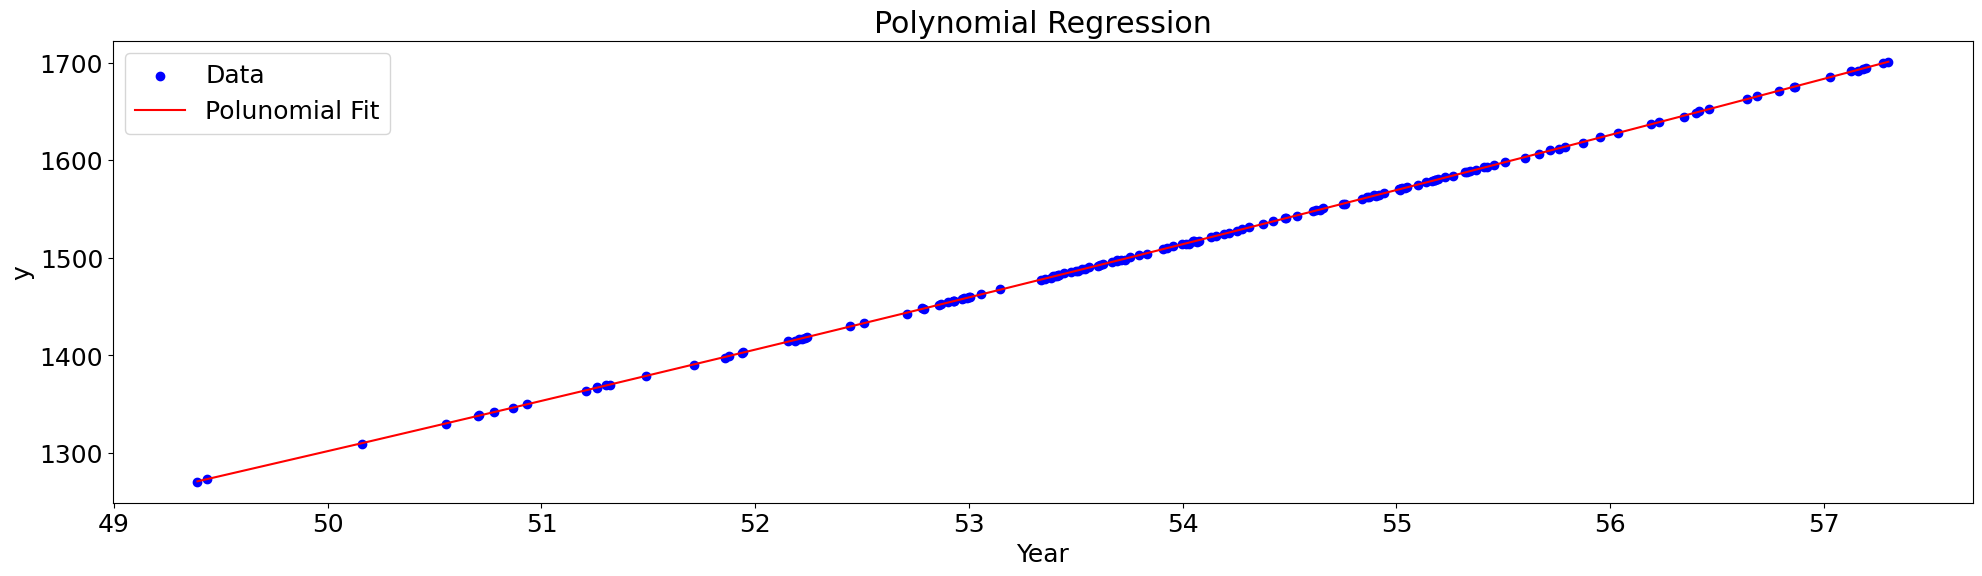

In [8]:
#For Year
X=np.array(df[['TempAvg']])
y=0.5*X**2+X+2+np.random.randn(X.shape[0], 1)* 0.5
y=y.flatten()
pr=PolynomialRegression(degree=2)
pr.fit(X, y)

print("Simple LR Coefficients: ", pr.coefficients_)
print("R2 Score: ", pr.r2score_)
print("y-intercept", pr.intercept_)

plt.figure(figsize=(24, 6))

plt.scatter(X, y, color='blue', label='Data')
plt.plot(np.sort(X, axis=0), pr.y_pred_[np.argsort(X, axis=0)], color='red', label='Polunomial Fit')

plt.title("Polynomial Regression")
plt.xlabel("Year")
plt.ylabel("y")
plt.legend()
plt.show()
plt.rc('font', size=18) 
